# Merge Dataset per Training ModernBERT

Unificazione di due dataset etichettati per creare un training set coerente:
- **PWC Distilled Balanced** (`pwc_distilled_balanced.csv`, ~28K righe, inglese) — distillato da Ministral 3B
- **Multiclass1** (`multiclass1.csv`, ~6.5K righe, italiano) — etichettato manualmente

Operazioni:
1. Merge classe "Virtual assistants" in "Enterprise" (riduzione class imbalance)
2. Mapping colonne e label di multiclass1 verso lo schema PWC
3. Concatenazione in un unico dataset a 9 classi
4. EDA del dataset risultante

**Output:** `data/training/bert_training_dataset.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Stile grafico
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Caricamento Dati

In [2]:
df_pwc = pd.read_csv('../data/distilled/pwc_distilled_balanced.csv')
df_mc = pd.read_csv('../data/labelled/multiclass1.csv')

print('=== PWC Distilled Balanced ===')
print(f'Shape: {df_pwc.shape}')
print(f'Colonne: {list(df_pwc.columns)}')
print(f'Classi ({df_pwc["Label"].nunique()}): {sorted(df_pwc["Label"].unique())}')
display(df_pwc.head(3))

print('\n=== Multiclass1 ===')
print(f'Shape: {df_mc.shape}')
print(f'Colonne: {list(df_mc.columns)}')
print(f'Classi ({df_mc["Label"].nunique()}): {sorted(df_mc["Label"].unique())}')
display(df_mc.head(3))

=== PWC Distilled Balanced ===
Shape: (28084, 2)
Colonne: ['description', 'Label']
Classi (10): ['Automotive & UVs', 'Enterprise', 'Environment', 'Fintech and Marketing', 'Generic use', 'Healthcare AI', 'Media & Entertainment', 'Research', 'Robotics and Industry', 'Virtual assistants']


,description,Label
0,strong demand for autonomous vehicles and the ...,Automotive & UVs
1,driving simulators play a large role in develo...,Automotive & UVs
2,a key functional block of visual navigation sy...,Automotive & UVs



=== Multiclass1 ===
Shape: (6483, 2)
Colonne: ['Descrizione', 'Label']
Classi (9): ['Autonomous driving', 'Data Science', 'Enterprise AI', 'Environmental AI', 'Fintech', 'Healthcare AI', 'Research', 'Robotics AI', 'Virtual assistants']


,Descrizione,Label
0,SVILUPPO DI UNA PROCEDURA AUTOMATIZZATA DI CAL...,Robotics AI
1,messa a punto di un sistema di Big Data Analyt...,Data Science
2,Implementazione sistemi di AI (artificial inte...,Enterprise AI


## 2. Preprocessing PWC Distilled

In [3]:
# Merge "Virtual assistants" -> "Enterprise"
df_pwc['Label'] = df_pwc['Label'].replace('Virtual assistants', 'Enterprise')
df_pwc['source'] = 'pwc_distilled'

print(f'Classi dopo merge VA ({df_pwc["Label"].nunique()}):')
print(df_pwc['Label'].value_counts())

Classi dopo merge VA (9):
Label
Environment              4000
Generic use              4000
Healthcare AI            4000
Research                 4000
Fintech and Marketing    3648
Robotics and Industry    2467
Automotive & UVs         2409
Enterprise               1867
Media & Entertainment    1693
Name: count, dtype: int64


## 3. Preprocessing Multiclass1

In [4]:
# Rimuovere Data Science
n_before = len(df_mc)
df_mc = df_mc[df_mc['Label'] != 'Data Science'].copy()
print(f'Rimossi {n_before - len(df_mc)} record "Data Science" ({n_before} -> {len(df_mc)})')

# Mapping label -> nomi PWC
LABEL_MAP = {
    'Autonomous driving': 'Automotive & UVs',
    'Enterprise AI': 'Enterprise',
    'Environmental AI': 'Environment',
    'Fintech': 'Fintech and Marketing',
    'Healthcare AI': 'Healthcare AI',
    'Research': 'Research',
    'Robotics AI': 'Robotics and Industry',
    'Virtual assistants': 'Enterprise',  # merge VA -> Enterprise
}

df_mc['Label'] = df_mc['Label'].map(LABEL_MAP)

# Verifica che il mapping sia completo (nessun NaN)
unmapped = df_mc['Label'].isna().sum()
if unmapped > 0:
    print(f'ATTENZIONE: {unmapped} record senza mapping!')
else:
    print('Mapping completato senza residui.')

# Rinomina colonna testo
df_mc = df_mc.rename(columns={'Descrizione': 'description'})
df_mc['source'] = 'multiclass1'

print(f'\nClassi dopo mapping ({df_mc["Label"].nunique()}):')
print(df_mc['Label'].value_counts())

Rimossi 101 record "Data Science" (6483 -> 6382)
Mapping completato senza residui.

Classi dopo mapping (7):
Label
Enterprise               3766
Environment               900
Healthcare AI             766
Robotics and Industry     667
Research                  136
Fintech and Marketing      75
Automotive & UVs           72
Name: count, dtype: int64


## 4. Merge dei Dataset

In [5]:
df = pd.concat([df_pwc[['description', 'Label', 'source']],
                df_mc[['description', 'Label', 'source']]],
               ignore_index=True)

print(f'=== DATASET UNIFICATO ===')
print(f'Righe totali:  {len(df):,}')
print(f'Colonne:       {list(df.columns)}')
print(f'Classi:        {df["Label"].nunique()}')
print(f'Valori nulli:  {df.isnull().sum().sum()}')
print(f'Duplicati:     {df.duplicated(subset="description").sum()}')

print(f'\nContributo per sorgente:')
print(df['source'].value_counts())

print(f'\nDistribuzione classi:')
print(df['Label'].value_counts())

=== DATASET UNIFICATO ===
Righe totali:  34,466
Colonne:       ['description', 'Label', 'source']
Classi:        9
Valori nulli:  0
Duplicati:     3508

Contributo per sorgente:
source
pwc_distilled    28084
multiclass1       6382
Name: count, dtype: int64

Distribuzione classi:
Label
Enterprise               5633
Environment              4900
Healthcare AI            4766
Research                 4136
Generic use              4000
Fintech and Marketing    3723
Robotics and Industry    3134
Automotive & UVs         2481
Media & Entertainment    1693
Name: count, dtype: int64


## 5. Distribuzione delle Classi

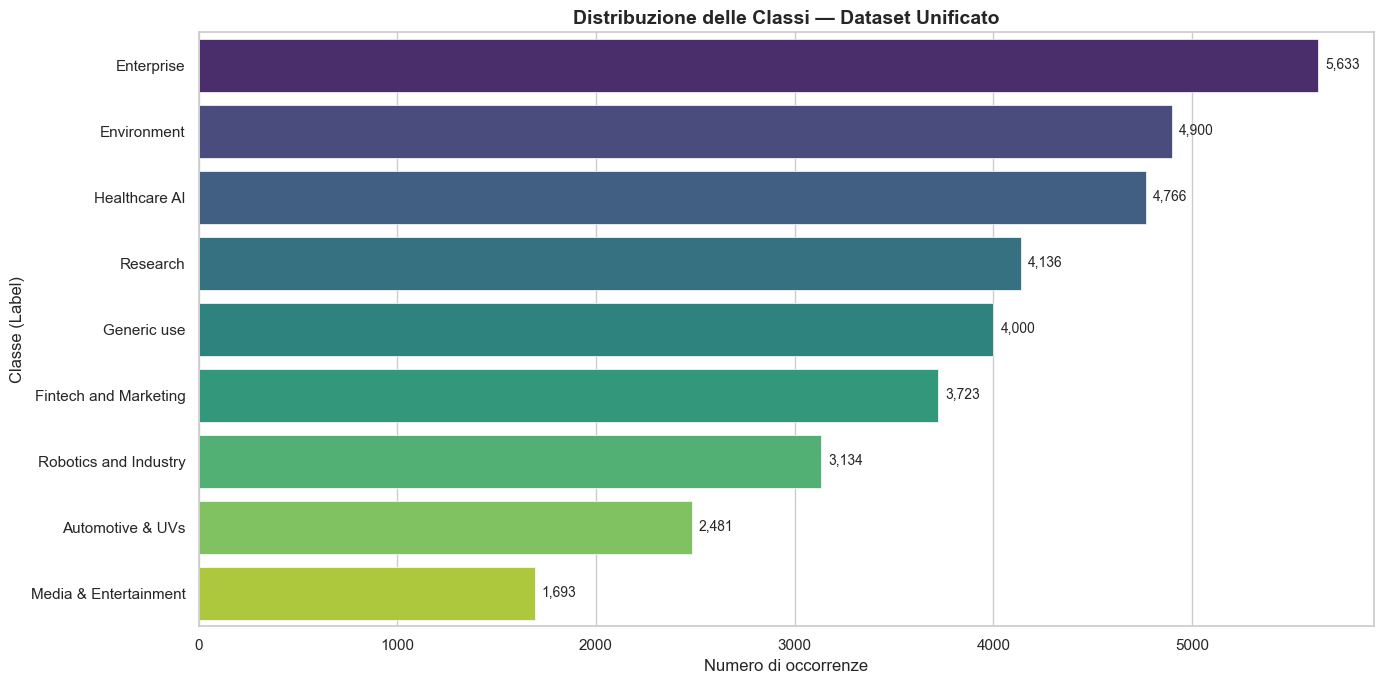

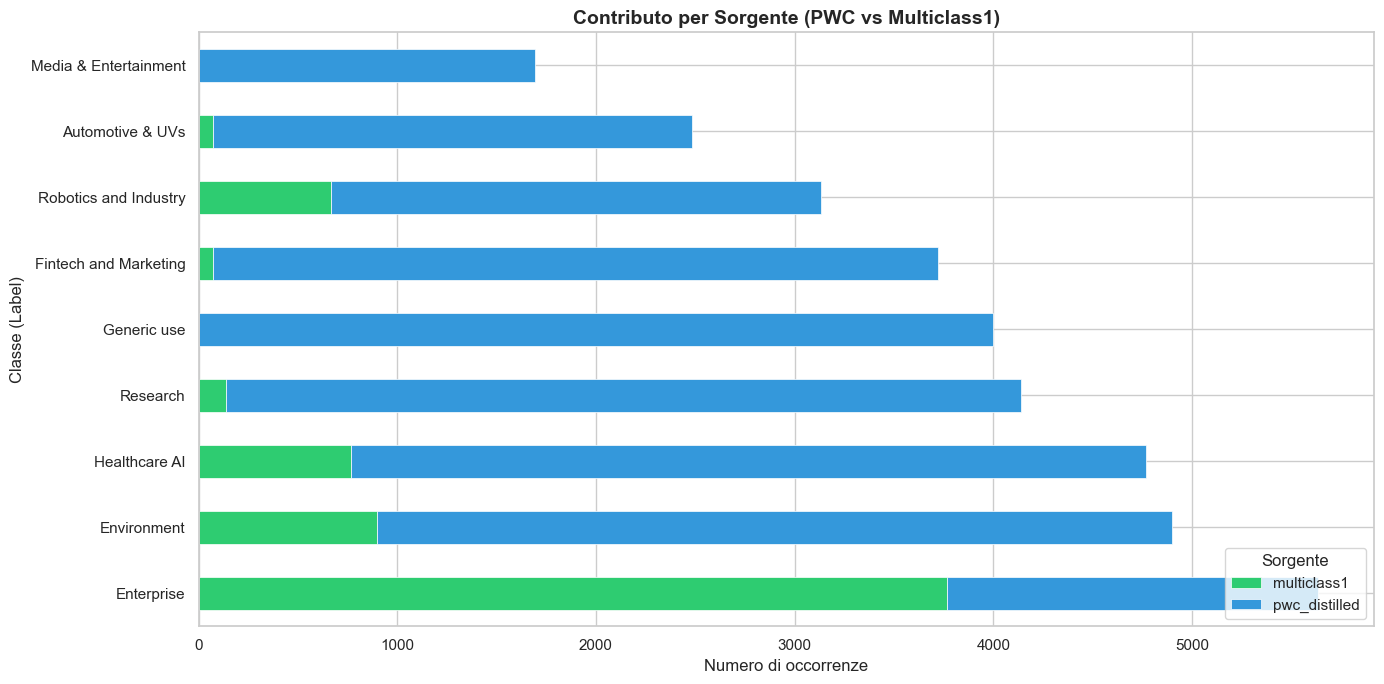

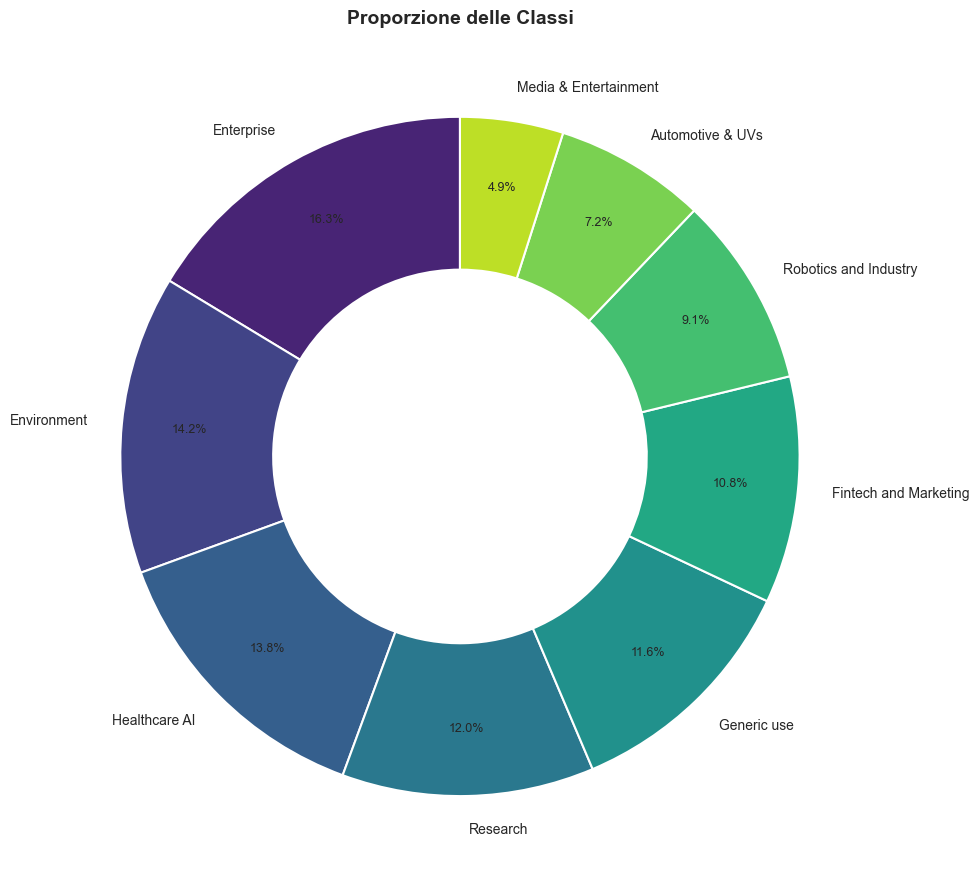

In [6]:
label_order = df['Label'].value_counts().index

# --- Barplot conteggi per classe ---
plt.figure(figsize=(14, 7))
ax = sns.countplot(data=df, y='Label', order=label_order,
                   palette='viridis', edgecolor='white', linewidth=0.5)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=5, fontsize=10)
ax.set_title('Distribuzione delle Classi — Dataset Unificato', fontsize=14, fontweight='bold')
ax.set_xlabel('Numero di occorrenze')
ax.set_ylabel('Classe (Label)')
plt.tight_layout()
plt.show()

# --- Barplot stacked per sorgente ---
cross = pd.crosstab(df['Label'], df['source'])
cross = cross.loc[label_order]

fig, ax = plt.subplots(figsize=(14, 7))
cross.plot.barh(stacked=True, ax=ax, color=['#2ecc71', '#3498db'], edgecolor='white', linewidth=0.5)
ax.set_title('Contributo per Sorgente (PWC vs Multiclass1)', fontsize=14, fontweight='bold')
ax.set_xlabel('Numero di occorrenze')
ax.set_ylabel('Classe (Label)')
ax.legend(title='Sorgente', loc='lower right')
plt.tight_layout()
plt.show()

# --- Donut chart ---
fig, ax = plt.subplots(figsize=(10, 10))
counts = df['Label'].value_counts()
colors = sns.color_palette('viridis', len(counts))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=colors, pctdistance=0.8, startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(9)
for t in texts:
    t.set_fontsize(10)
ax.set_title('Proporzione delle Classi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Analisi Lunghezza Descrizioni

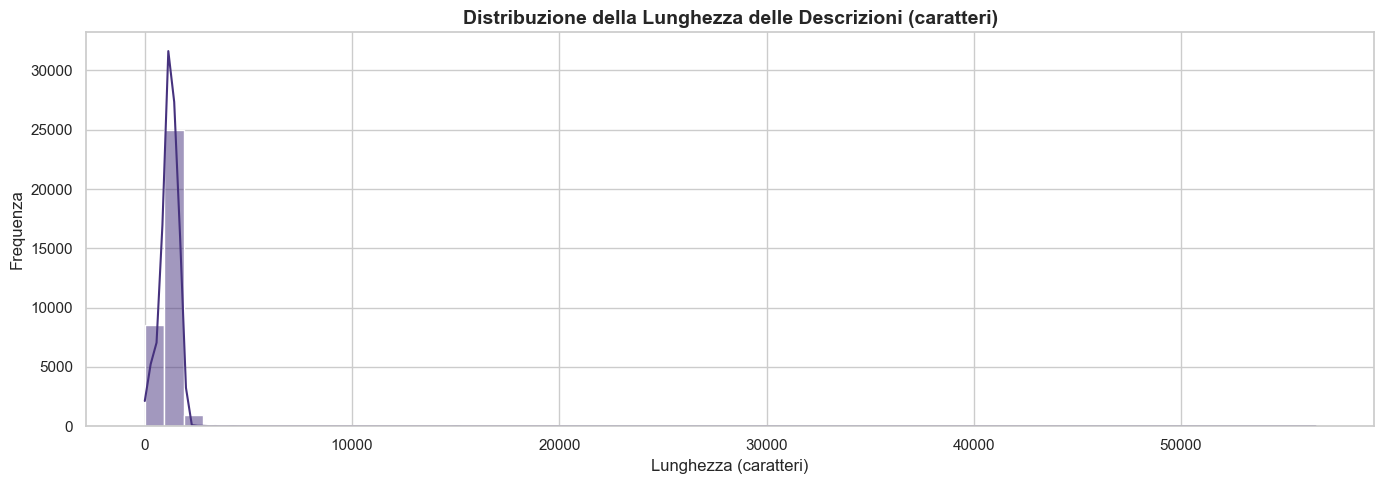

Statistiche globali:


,count,mean,std,min,25%,50%,75%,max
desc_length,34466.0,1178.440376,533.061326,1.0,947.0,1223.0,1465.0,56487.0


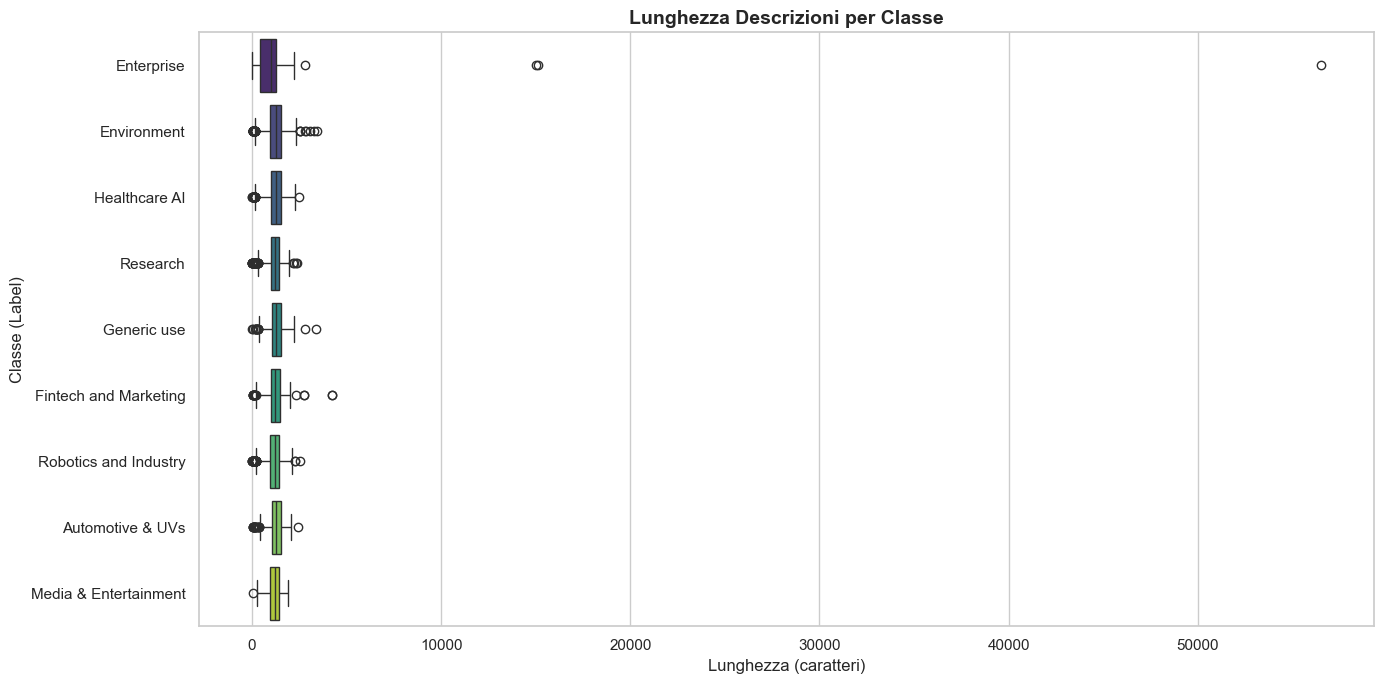

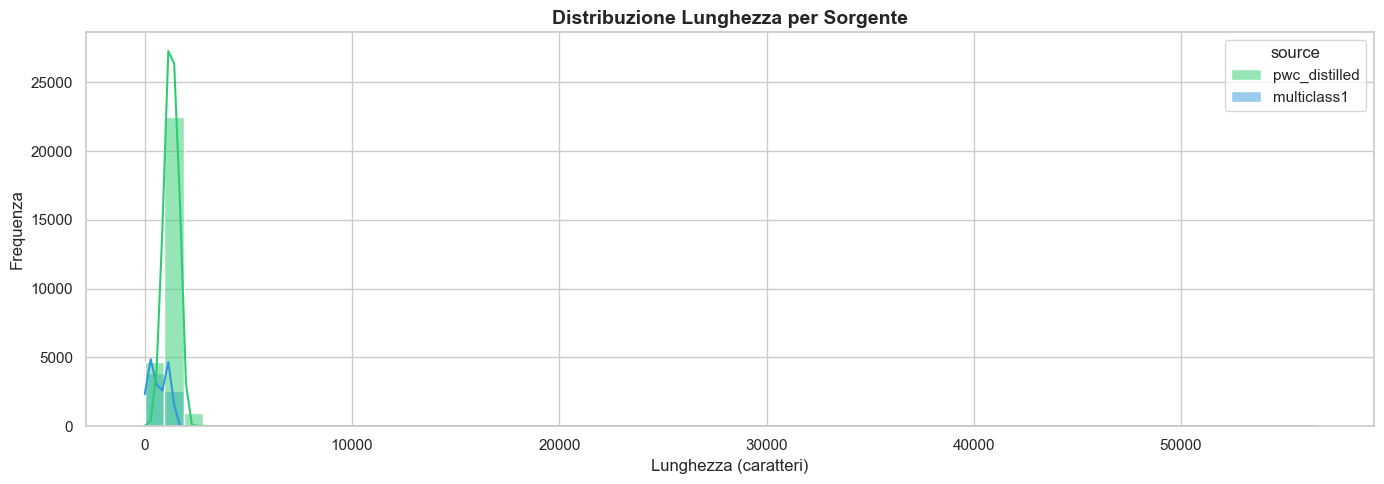


Statistiche per classe:


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
Enterprise,5633.0,913.987218,934.175014,7.0,437.00,1014.0,1289.00,56487.0
Environment,4900.0,1216.778980,451.549214,38.0,982.00,1270.0,1539.00,3427.0
Healthcare AI,4766.0,1235.181284,429.868791,12.0,990.25,1271.0,1552.75,2483.0
Research,4136.0,1213.739845,354.238078,2.0,999.75,1227.0,1448.00,2405.0
Generic use,4000.0,1284.452250,344.119519,1.0,1046.75,1289.0,1520.00,3393.0
Fintech and Marketing,3723.0,1237.834273,369.404939,59.0,983.00,1231.0,1497.00,4218.0
Robotics and Industry,3134.0,1153.893427,405.435841,23.0,932.25,1198.0,1418.00,2568.0
Automotive & UVs,2481.0,1286.923821,333.356278,35.0,1072.00,1290.0,1522.00,2453.0
Media & Entertainment,1693.0,1206.787360,340.282445,68.0,981.00,1203.0,1458.00,1931.0


In [7]:
df['desc_length'] = df['description'].astype(str).str.len()

# Distribuzione globale
plt.figure(figsize=(14, 5))
sns.histplot(df['desc_length'], bins=60, kde=True, color=sns.color_palette('viridis')[0])
plt.title('Distribuzione della Lunghezza delle Descrizioni (caratteri)', fontsize=14, fontweight='bold')
plt.xlabel('Lunghezza (caratteri)')
plt.ylabel('Frequenza')
plt.tight_layout()
plt.show()

print('Statistiche globali:')
display(df['desc_length'].describe().to_frame('desc_length').T)

# Boxplot per classe
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='desc_length', y='Label', order=label_order, palette='viridis')
plt.title('Lunghezza Descrizioni per Classe', fontsize=14, fontweight='bold')
plt.xlabel('Lunghezza (caratteri)')
plt.ylabel('Classe (Label)')
plt.tight_layout()
plt.show()

# Histplot per sorgente
plt.figure(figsize=(14, 5))
sns.histplot(data=df, x='desc_length', hue='source', bins=60, kde=True, palette=['#2ecc71', '#3498db'])
plt.title('Distribuzione Lunghezza per Sorgente', fontsize=14, fontweight='bold')
plt.xlabel('Lunghezza (caratteri)')
plt.ylabel('Frequenza')
plt.tight_layout()
plt.show()

print('\nStatistiche per classe:')
display(df.groupby('Label')['desc_length'].describe().sort_values('count', ascending=False))

## 7. Metriche di Bilanciamento

Classe maggioritaria: Enterprise (5,633)
Classe minoritaria:   Media & Entertainment (1,693)
Imbalance Ratio:      3.3x

Entropia:                3.098 bit
Entropia max (uniforme): 3.170 bit
Entropia normalizzata:   0.977 (1.0 = perfettamente bilanciato)


,count,%,cumulative_%
Label,,,
Enterprise,5633,16.34,16.34
Environment,4900,14.22,30.56
Healthcare AI,4766,13.83,44.39
Research,4136,12.00,56.39
Generic use,4000,11.61,68.00
Fintech and Marketing,3723,10.80,78.80
Robotics and Industry,3134,9.09,87.89
Automotive & UVs,2481,7.20,95.09
Media & Entertainment,1693,4.91,100.00


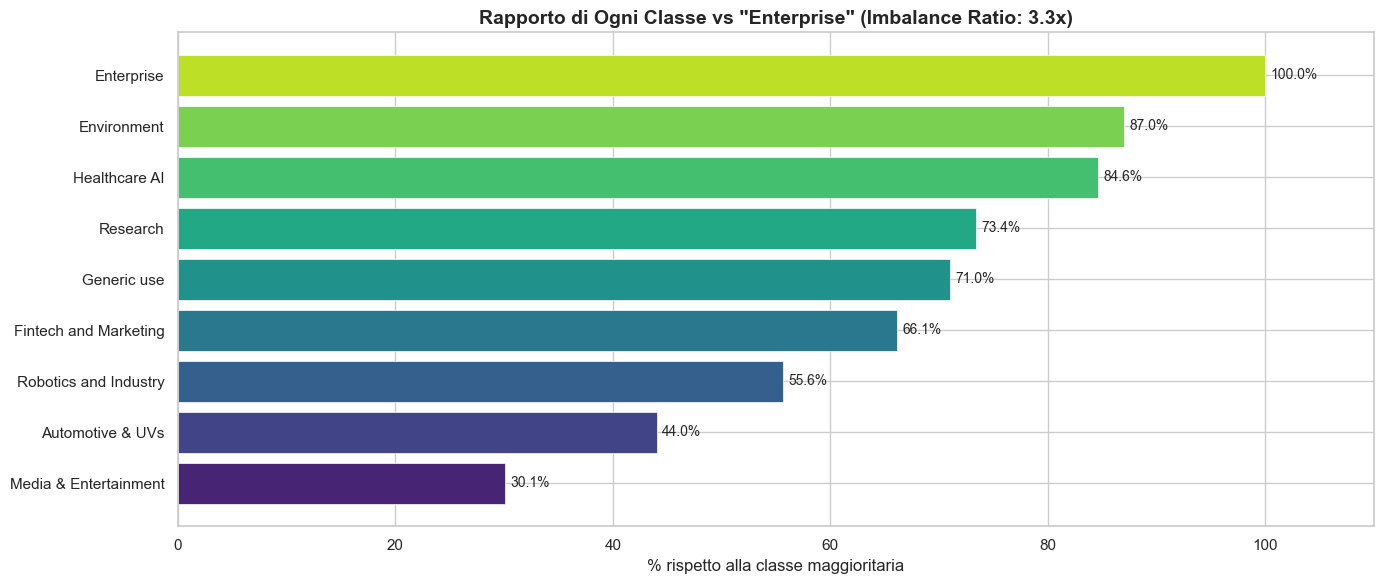

In [8]:
counts = df['Label'].value_counts()
max_class = counts.iloc[0]
min_class = counts.iloc[-1]

# Imbalance ratio
imbalance_ratio = max_class / min_class
print(f'Classe maggioritaria: {counts.index[0]} ({max_class:,})')
print(f'Classe minoritaria:   {counts.index[-1]} ({min_class:,})')
print(f'Imbalance Ratio:      {imbalance_ratio:,.1f}x')

# Entropia normalizzata
probs = counts.values / counts.values.sum()
entropy = -np.sum(probs * np.log2(probs))
max_entropy = np.log2(len(counts))
normalized_entropy = entropy / max_entropy
print(f'\nEntropia:                {entropy:.3f} bit')
print(f'Entropia max (uniforme): {max_entropy:.3f} bit')
print(f'Entropia normalizzata:   {normalized_entropy:.3f} (1.0 = perfettamente bilanciato)')

# Tabella riassuntiva
label_stats = counts.to_frame('count')
label_stats['%'] = (label_stats['count'] / len(df) * 100).round(2)
label_stats['cumulative_%'] = label_stats['%'].cumsum().round(2)
display(label_stats)

# Bar chart rapporto vs maggioritaria
fig, ax = plt.subplots(figsize=(14, 6))
ratios = (counts / max_class * 100).sort_values(ascending=True)
colors = sns.color_palette('viridis', len(ratios))
bars = ax.barh(ratios.index, ratios.values, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, ratios.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% rispetto alla classe maggioritaria')
ax.set_title(f'Rapporto di Ogni Classe vs "{counts.index[0]}" (Imbalance Ratio: {imbalance_ratio:,.1f}x)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

## 8. Salvataggio

In [9]:
# Drop colonne ausiliarie per il CSV finale
df_out = df[['description', 'Label']].copy()

out_path = Path('../data/training/bert_training_dataset.csv')
df_out.to_csv(out_path, index=False)

print(f'Dataset salvato in: {out_path}')
print(f'Righe:   {len(df_out):,}')
print(f'Classi:  {df_out["Label"].nunique()}')
print(f'\nClassi finali:')
for label in sorted(df_out['Label'].unique()):
    print(f'  - {label}')

# Verifica finale
assert df_out['Label'].nunique() == 9, f'Attese 9 classi, trovate {df_out["Label"].nunique()}'
assert 'Virtual assistants' not in df_out['Label'].values, 'Trovati record Virtual assistants!'
assert 'Data Science' not in df_out['Label'].values, 'Trovati record Data Science!'
print('\nVerifiche superate.')

Dataset salvato in: ..\data\training\bert_training_dataset.csv
Righe:   34,466
Classi:  9

Classi finali:
  - Automotive & UVs
  - Enterprise
  - Environment
  - Fintech and Marketing
  - Generic use
  - Healthcare AI
  - Media & Entertainment
  - Research
  - Robotics and Industry

Verifiche superate.


## Riepilogo

**Operazioni effettuate:**
- "Virtual assistants" fusa in "Enterprise" in entrambi i dataset
- "Data Science" rimossa dal dataset multiclass1
- Label di multiclass1 mappate allo schema PWC Distilled
- Dataset concatenati in un unico training set

**Dataset finale:** 9 classi, salvato in `data/training/bert_training_dataset.csv`